In [51]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [52]:
load_dotenv()

True

In [53]:
model = ChatGroq(model = 'llama-3.3-70b-versatile')
print(model)

output_version=None profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x000001E6193A4D60> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E6193A56E0> model_name='llama-3.3-70b-versatile' model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None


In [54]:
class State(TypedDict):
    runs : int
    balls : int
    fours : int
    sixes : int

    sr : float
    bpb : float
    boundary_percent: float
    summary: str

In [55]:
def cal_sr(state : State):
    sr = (state['runs'] / state['balls']) * 100

    return {'sr' : sr}

In [56]:
def cal_bpb(state : State):
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb' : bpb}

In [57]:
def cal_boundary_percent(state : State):
     
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100
    return {'boundary_percent' : boundary_percent}

In [58]:
def summary(state : State):
    summary = f""" 
Strike Rate - {state['sr']} \n
Balls Per Boundary - {state['bpb']} \n
Boundery Percent - {state['boundary_percent']}
"""
    return {'summary' : summary}

In [59]:
graph = StateGraph(State)

graph.add_node('cal_sr', cal_sr)
graph.add_node('cal_bpb', cal_bpb)
graph.add_node('cal_boundary_percent', cal_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'cal_sr')
graph.add_edge(START, 'cal_bpb')
graph.add_edge(START, 'cal_boundary_percent')
graph.add_edge('cal_sr', 'summary')
graph.add_edge('cal_bpb', 'summary')
graph.add_edge('cal_boundary_percent', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()


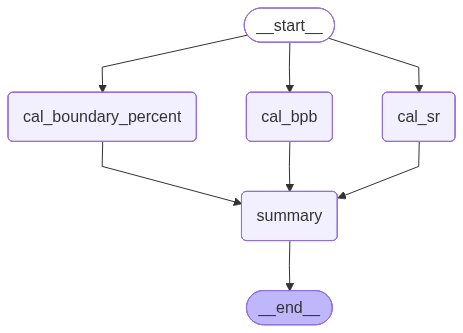

In [60]:
workflow

In [61]:
intial_state = {
    'runs' : 100,
    'balls' : 50,
    'fours' : 6,
    'sixes' : 4
}

final_state = workflow.invoke(intial_state)

In [64]:
workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': ' \nStrike Rate - 200.0 \n\nBalls Per Boundary - 5.0 \n\nBoundery Percent - 48.0\n'}

In [62]:
print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percent': 48.0, 'summary': ' \nStrike Rate - 200.0 \n\nBalls Per Boundary - 5.0 \n\nBoundery Percent - 48.0\n'}
